In [1]:
from utils import *

## Load PCA Layers definitions from YAML

In [2]:
## Define PCA dataset to use. This will be used in the output file names
pca_dataset = 'pca_nominations'
pca_status_filter = [
    'final/submit',
    'draft'
    ]
datestamp = datetime.now().strftime("%Y%m%d")

## Define Evaluation output files
eval_type_file = f'pca_type_assignment_{pca_dataset}_{datestamp}.csv'
eval_matrix_file = f'pca_matrix_{pca_dataset}_{datestamp}.csv'
eval_dir = '_data/evaluation_assignments'

print('Evaluation Output files will be saved to the Evaluation directory:', eval_dir)

Evaluation Output files will be saved to the Evaluation directory: _data/evaluation_assignments


In [3]:
## Load data dictionary
pca_data = load_dict_from_yaml()
[print(f"{k}: {v['use']}") for k,v in pca_data.items()]

pca: pca_geographies
pca_ammend: pca_geographies
pca_nominations: pca_geographies
natural_land: pca_type
working_land: pca_type
urban_greening: pca_type
recreation: pca_type
climate_adaptation: pca_type
ugb: ugb


[None, None, None, None, None, None, None, None, None]

In [4]:
## Create subset dictionaries
## PCA Geographies. Select either 'pca' or 'pca_ammend' for the PCA geographies

## Option A: PCA
# pca_geo = pca_data['pca']

## Option B: PCA DRAFT Amendement
# pca_geo = pca_data['pca_ammend']

## Option C: PCA Nominations (From PCA Nomination Tool)
pca_geo = pca_data[pca_dataset]

# PCA Types
pca_types = create_subset_dict(pca_data, 'use', 'pca_type')
# UGB
ugb = pca_data['ugb']

## Load PCA Layers from Feather Files

Shape__Area and Shape__Length columns dropped from the data_load dataframe
chng_status
draft           84
final/submit    60
dtype: int64


<Axes: >

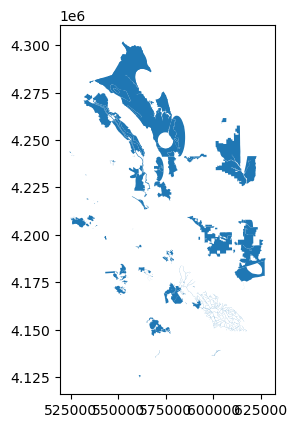

In [5]:
## Load PCA Geographies from Feather file
# pca_geo['data_load'] = open_feather(pca_geo['filename'])

## Load PCA Geographies from GeoJSON file
pca_geo['data_load'] = gpd.read_file('_data/geojson_files/priority_conservation_area_bndy_wrk.geojson') ## Use Output to GeoJSON
pca_geo['data_load'] = pca_geo['data_load'].to_crs('EPSG:26910')
try:
    pca_geo['data_load'] = pca_geo['data_load'].drop(columns=['Shape__Area', 'Shape__Length'])
    print('Shape__Area and Shape__Length columns dropped from the data_load dataframe')
except:
    pass

## Apply Status filter
pca_geo['data'] = pca_geo['data_load'][pca_geo['data_load']['chng_status'].isin(pca_status_filter)]

## Process PCA Geographies
process_data_load(pca_geo, data_key='data')
print(pca_geo['data'].groupby('chng_status').size())

pca_geo['data'].plot()

## Load PCA Footprints from Feather Files

Loading data for natural_land
Opening file from _data/feather_files/natural_land_footprint.feather
Footprint loaded successfully from natural_land_footprint

Loading data for working_land
Opening file from _data/feather_files/working_land_footprint.feather
Footprint loaded successfully from working_land_footprint

Loading data for urban_greening
Opening file from _data/feather_files/urban_greening_footprint.feather
Footprint loaded successfully from urban_greening_footprint

Loading data for recreation
Opening file from _data/feather_files/recreation_footprint.feather
Footprint loaded successfully from recreation_footprint

Loading data for climate_adaptation
Opening file from _data/feather_files/climate_adaptation_footprint.feather
Footprint loaded successfully from climate_adaptation_footprint



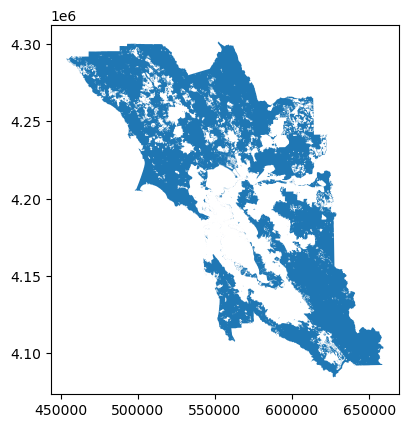

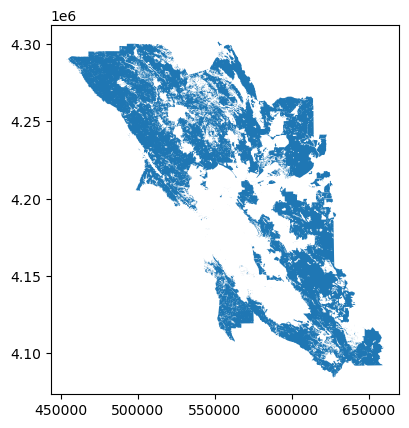

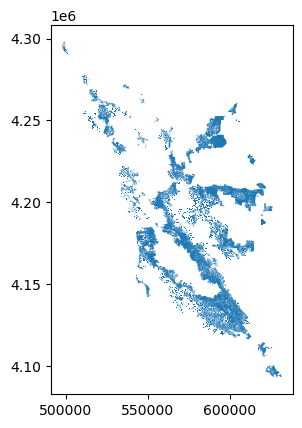

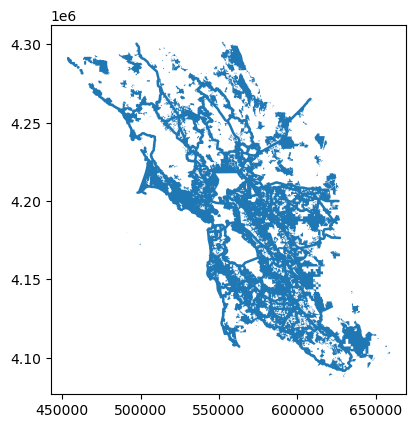

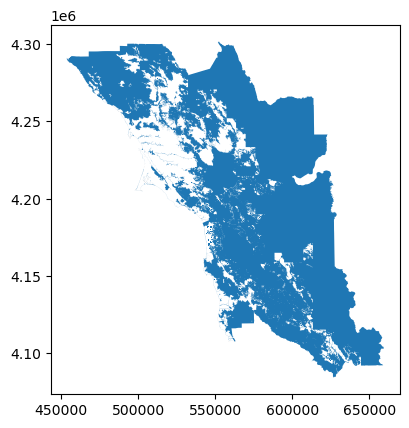

In [6]:
load_footprints_for_dict(pca_types)

## Evaluation Assignment #1 PCA Geographies to PCA Types

### Assign PCA Type Footprints to PCA Geographies

In [7]:
assign_footprints_from_dictionary(pca_geo, pca_types, 'flag')

Dataset natural_land: Starting Assignment of Footprint
Creating Base GeoDataframe to Overlay GeoDataframe correspondence


/Users/LElias/opt/anaconda3/envs/mtcpy-env/lib/python3.12/site-packages/geopandas/geodataframe.py:1819: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)


took 1.5758 seconds
Calculating area_sq_m
Dataset natural_land: Assignment of Footprint complete

Dataset working_land: Starting Assignment of Footprint
Creating Base GeoDataframe to Overlay GeoDataframe correspondence


/Users/LElias/opt/anaconda3/envs/mtcpy-env/lib/python3.12/site-packages/geopandas/geodataframe.py:1819: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)


took 3.5877 seconds
Calculating area_sq_m
Dataset working_land: Assignment of Footprint complete

Dataset urban_greening: Starting Assignment of Footprint
Creating Base GeoDataframe to Overlay GeoDataframe correspondence


/Users/LElias/opt/anaconda3/envs/mtcpy-env/lib/python3.12/site-packages/geopandas/geodataframe.py:1819: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)


took 12.1837 seconds
Calculating area_sq_m
Dataset urban_greening: Assignment of Footprint complete

Dataset recreation: Starting Assignment of Footprint
Creating Base GeoDataframe to Overlay GeoDataframe correspondence


/Users/LElias/opt/anaconda3/envs/mtcpy-env/lib/python3.12/site-packages/geopandas/geodataframe.py:1819: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)


took 2.9625 seconds
Calculating area_sq_m
Dataset recreation: Assignment of Footprint complete

Dataset climate_adaptation: Starting Assignment of Footprint
Creating Base GeoDataframe to Overlay GeoDataframe correspondence
took 14.118 seconds
Calculating area_sq_m
Dataset climate_adaptation: Assignment of Footprint complete



/Users/LElias/opt/anaconda3/envs/mtcpy-env/lib/python3.12/site-packages/geopandas/geodataframe.py:1819: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)


In [8]:
## Display Assignment of Footprint for PCA Types
for pca_type, type_att in pca_types.items():
    try:
        print('Displaying Assignment of Footprint for PCA Type:', pca_type)
        display(type_att['assignment'].sample(3))
    except:
        print(f'Display of Assignment of Footprint for PCA Type {pca_type} failed!')

Displaying Assignment of Footprint for PCA Type: natural_land


,OBJECTID,joinkey,jurisdctn,name,lead,cntct_name,cntct_mail,edit_name,edit_mail,typenl,...,Editor,chng_status,JoinKeyNew,gdf_id,area_sq_m,1nl,base_sq_m,1nl_intersect_sq_m,area_share,1nl_share_pct
138,336,None,City of San Pablo,Wallnass Park,None,None,None,None,None,None,...,klyons@bayareametro.gov_MTC,draft,None,139,19926.716057,NaN,19926.716057,NaN,NaN,NaN
108,240,None,Menlo Park,Menlo Park and East Palo Alto Baylands (Rec),City of Menlo Park,None,None,None,None,No,...,pmilliken@bayareametro.gov_MTC,draft,None,109,672221.348794,1.0,672221.348794,46694.862007,0.069464,0.069464
70,199,None,City of Alameda,Encinal Terminals Bay Trail,City of Alameda,Steven Buckley,sbuckley@alamedaca.gov,Steven Buckley,sbuckley@alamedaca.gov,None,...,,draft,None,71,12776.462275,1.0,12776.462275,1077.696330,0.084350,0.084350


Displaying Assignment of Footprint for PCA Type: working_land


,OBJECTID,joinkey,jurisdctn,name,lead,cntct_name,cntct_mail,edit_name,edit_mail,typenl,...,Editor,chng_status,JoinKeyNew,gdf_id,area_sq_m,1wl,base_sq_m,1wl_intersect_sq_m,area_share,1wl_share_pct
63,191,None,City and County of San Francisco,SF Core,SF Planning,Joshua Switzky,Joshua.Switzky@sfgov.org,David H. Garcia,David.H. Garcia@sfgov.org,No,...,,final/submit,None,64,7.525780e+06,NaN,7.525780e+06,NaN,NaN,NaN
21,71,SL101,Vallejo,White Slough Wetlands Area,City of Vallejo,None,None,None,None,Yes,...,klyons@bayareametro.gov_MTC,final/submit,None,22,6.577576e+05,1.0,6.577576e+05,528747.877545,0.803864,0.803864
25,88,None,City of Cotati,McGinnis Open Space,City of Cotati,Autumn Buss,abuss@cotaticity.gov,Noah Housh,nhoush@cotaticity.gov,No,...,klyons@bayareametro.gov_MTC,final/submit,SN19,26,8.592333e+03,NaN,8.592333e+03,NaN,NaN,NaN


Displaying Assignment of Footprint for PCA Type: urban_greening


,OBJECTID,joinkey,jurisdctn,name,lead,cntct_name,cntct_mail,edit_name,edit_mail,typenl,...,Editor,chng_status,JoinKeyNew,gdf_id,area_sq_m,1ug,base_sq_m,1ug_intersect_sq_m,area_share,1ug_share_pct
134,315,None,County of Alameda,Bay Trees,Bay Trees,Thomas Omolo,omot@haywardrec.org,Thomas Omolo,omot@haywardrec.org,Yes,...,klyons@bayareametro.gov_MTC,draft,None,135,50441.137279,1.0,50441.137279,15108.685325,0.299531,0.299531
93,224,None,City of Alameda,College of Alameda Detention,City of Alameda,Steven Buckley,sbuckley@alamedaca.gov,Steven Buckley,sbuckley@alamedaca.gov,None,...,,draft,None,94,31522.993240,1.0,31522.993240,31522.993240,1.000000,1.000000
115,250,None,County of Alameda,Valley View,Hayward Area Recreation & Park District,Thomas Omolo,omot@haywardrec.org,Thomas Omolo,omot@haywardrec.org,Yes,...,klyons@bayareametro.gov_MTC,draft,None,116,81056.741600,1.0,81056.741600,59523.690716,0.734346,0.734346


Displaying Assignment of Footprint for PCA Type: recreation


,OBJECTID,joinkey,jurisdctn,name,lead,cntct_name,cntct_mail,edit_name,edit_mail,typenl,...,Editor,chng_status,JoinKeyNew,gdf_id,area_sq_m,1r,base_sq_m,1r_intersect_sq_m,area_share,1r_share_pct
93,224,None,City of Alameda,College of Alameda Detention,City of Alameda,Steven Buckley,sbuckley@alamedaca.gov,Steven Buckley,sbuckley@alamedaca.gov,None,...,,draft,None,94,31522.993240,1,31522.993240,31522.993240,1.000000,1.000000
79,210,None,City of Alameda,Lincoln Park,City of Alameda,Steven Buckley,sbuckley@alamedaca.gov,Steven Buckley,sbuckley@alamedaca.gov,None,...,,draft,None,80,34402.855217,1,34402.855217,34402.855217,1.000000,1.000000
21,71,SL101,Vallejo,White Slough Wetlands Area,City of Vallejo,None,None,None,None,Yes,...,klyons@bayareametro.gov_MTC,final/submit,None,22,657757.612589,1,657757.612589,657313.148327,0.999324,0.999324


Displaying Assignment of Footprint for PCA Type: climate_adaptation


,OBJECTID,joinkey,jurisdctn,name,lead,cntct_name,cntct_mail,edit_name,edit_mail,typenl,...,Editor,chng_status,JoinKeyNew,gdf_id,area_sq_m,1ca,base_sq_m,1ca_intersect_sq_m,area_share,1ca_share_pct
130,310,None,City of San Pablo,Wallnass Park,None,None,None,None,None,None,...,klyons@bayareametro.gov_MTC,draft,None,131,1.992672e+04,1,1.992672e+04,1.992672e+04,1.000000,1.000000
33,132,None,City of Alameda,Roemer Bird Sanctuary,City of Alameda,Steven Buckley,sbuckley@alamedaca.gov,Steven Buckley,sbuckley@alamedaca.gov,Yes,...,,draft,None,34,3.090114e+04,1,3.090114e+04,2.689034e+04,0.870205,0.870205
3,6,SL1,Fairfield,Vacaville-Fairfield-Solano Greenbelt (WL),City of Fairfield,None,None,None,None,No,...,,draft,None,4,5.836794e+06,1,5.836794e+06,5.836794e+06,1.000000,1.000000


### Integrate Assignments of PCA Types into single Assignment file

In [9]:
## Prepare PCA Types Assignments
pca_geo['assignment'] = pca_geo[data_key(pca_geo)].drop(columns=['geometry'])
## Merge PCA Geographies to PCA Types Assignments 
for pca_type, type_att in pca_types.items():
    try:
        flag = type_att['flag']
        cols = ['gdf_id', flag, f"{flag}_intersect_sq_m", f"{flag}_share_pct"]
        pca_geo['assignment'] = pd.merge(
            pca_geo['assignment'],
            type_att['assignment'][cols].fillna(0),
            on='gdf_id',
            how='left'
            )
        print(f'Assignment of Footprint for PCA Type {pca_type} completed\n')
    except:
        print(f'Assignment of Footprint for PCA Type {pca_type} failed!\n')

Assignment of Footprint for PCA Type natural_land completed

Assignment of Footprint for PCA Type working_land completed

Assignment of Footprint for PCA Type urban_greening completed

Assignment of Footprint for PCA Type recreation completed

Assignment of Footprint for PCA Type climate_adaptation completed



## Evaluation Assignment #2 PCA to UGB

### Load Footprint for UGB

Opening file from _data/feather_files/ugb_footprint.feather


<Axes: >

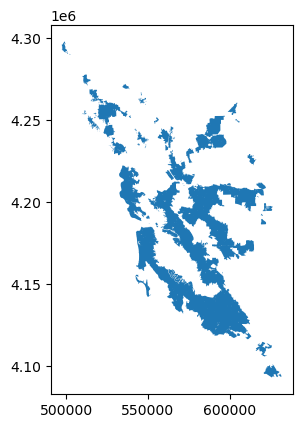

In [10]:
## Load UGB Footprint from Feather file
footprint_filename = f"{ugb['filename']}_footprint"
ugb["footprint"] = open_feather(footprint_filename)
ugb['footprint'].plot()

### Assign UGB Footprint to PCA Geographies

In [11]:
print(f"Dataset {ugb['name']}: Starting Assignment of Footprint")
print(f"Using: {data_key(pca_geo)}")
flag_name = ugb['flag']
ugb['assignment'] = assign_footprint(
    gdf_base=pca_geo[data_key(pca_geo)],
    gdf_over=ugb['footprint'],
    flag_name = flag_name
    )
print(f"Dataset {ugb['name']}: Assignment of Footprint complete\n")

Dataset EN4_Urban_Growth_Boundary: Starting Assignment of Footprint
Using: data
Creating Base GeoDataframe to Overlay GeoDataframe correspondence
took 0.8682 seconds
Calculating area_sq_m
Dataset EN4_Urban_Growth_Boundary: Assignment of Footprint complete



/Users/LElias/opt/anaconda3/envs/mtcpy-env/lib/python3.12/site-packages/geopandas/geodataframe.py:1819: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)


In [12]:
ugb['assignment'].sample(3).T

,38,43,41
OBJECTID,139,150,147
joinkey,None,None,None
jurisdctn,San Anselmo,City of Alameda,City and County of San Francisco
name,Sorich Ranch,Main St Ferry Waterfront,Twin Peaks and Glen Cayon Bioregion - Expansion
lead,Town of San Anselmo,City of Alameda,SF Planning
cntct_name,Lindsey Klein,Steven Buckley,Joshua Switzky
cntct_mail,lklein@sananselmo.gov,sbuckley@alamedaca.gov,joshua.switzky@sfgov.org
edit_name,Lindsey Klein,Steven Buckley,David H Garcia
edit_mail,lklein@sananselmo.gov,sbuckley@alamedaca.gov,david.h.garcia@sfgov.org
typenl,No,None,Yes


### Integrate Assignments of UGB to single Assignment file

In [13]:
## Assign UGB Footprint to PCA Geographies
## Assignment #1 should be run first
flag = ugb['flag']
cols = ['gdf_id', flag, f"{flag}_intersect_sq_m", f"{flag}_share_pct"]
pca_geo['assignment'] = pd.merge(
            pca_geo['assignment'],
            ugb['assignment'][cols].fillna(0),
            on='gdf_id',
            how='left'
            )
print(f"Assignment of Footprint for {ugb['flag']} completed")

Assignment of Footprint for ugb completed


### Check samples from Integrated Assignments table

In [14]:
pca_geo['assignment'].sample(3).T

,9,53,82
OBJECTID,38,162,213
joinkey,SM10,None,None
jurisdctn,Menlo Park,Portola Valley,City of Alameda
name,Menlo Park and East Palo Alto Baylands (NL),Alpine Road Scenic Corridor,Franklin Park
lead,City of Menlo Park,Town of Portola Valley,City of Alameda
cntct_name,None,Rebecca Flynn,Steven Buckley
cntct_mail,None,rflynn@portolavalley.net,sbuckley@alamedaca.gov
edit_name,None,Catherine Magill,Steven Buckley
edit_mail,None,magill_catherine@yahoo.com,sbuckley@alamedaca.gov
typenl,Yes,No,None


### Export Integrated Assignments #1 and #2 as Table

In [15]:
col_order = ['gdf_id'] + [c for c in pca_geo['assignment'].columns if c != 'gdf_id']
pca_geo['assignment'][col_order].fillna(0).to_csv(os.path.join(eval_dir, eval_type_file), index=False)

## Evaluation Assignment #3 PCA to PCA

In [16]:
# Perform the overlay matrix operation
pca_geo['matrix'] = overlay_surface_percentage_matrix(
    pca_geo['data'], 
    id_column='gdf_id', 
    how='intersection'
    )

Processing feature 1 of 144
Processing feature 2 of 144
Processing feature 3 of 144
Processing feature 4 of 144
Processing feature 5 of 144
Processing feature 6 of 144
Processing feature 7 of 144
Processing feature 8 of 144
Processing feature 9 of 144
Processing feature 10 of 144
Processing feature 11 of 144
Processing feature 12 of 144
Processing feature 13 of 144
Processing feature 14 of 144
Processing feature 15 of 144
Processing feature 16 of 144
Processing feature 17 of 144
Processing feature 18 of 144
Processing feature 19 of 144
Processing feature 20 of 144
Processing feature 21 of 144
Processing feature 22 of 144
Processing feature 23 of 144
Processing feature 24 of 144
Processing feature 25 of 144
Processing feature 26 of 144
Processing feature 27 of 144
Processing feature 28 of 144
Processing feature 29 of 144
Processing feature 30 of 144
Processing feature 31 of 144
Processing feature 32 of 144
Processing feature 33 of 144
Processing feature 34 of 144
Processing feature 35 o

### Export PCA to PCA Overlay Matrix

In [17]:
pca_geo['matrix'].fillna(0).to_csv(os.path.join(eval_dir, eval_matrix_file), index=True)

## Additional Checks and Exports

### Additional Exports

In [18]:
pca_geo['data'].to_file('_data/pca_data.geojson', driver='GeoJSON')


### Additional Checks

In [19]:
## Spot check
df = pca_types['working_land']['assignment']
df[df['joinkey'] == 'SL105']

# ## Spot check
# pca_geo['data'][pca_geo['data']['joinkey'] == 'SL105'].plot()
# pca_geo['data'][pca_geo['data']['joinkey'] == 'SL105'].geometry.area

,OBJECTID,joinkey,jurisdctn,name,lead,cntct_name,cntct_mail,edit_name,edit_mail,typenl,...,Editor,chng_status,JoinKeyNew,gdf_id,area_sq_m,1wl,base_sq_m,1wl_intersect_sq_m,area_share,1wl_share_pct
20,70,SL105,Solano County,Cache Slough,Solano County,None,None,None,None,No,...,,final/submit,None,21,2.998807e+08,1.0,2.998807e+08,2.733335e+08,0.911474,0.911474


In [20]:
## Spot check
df = pca_types['natural_land']['assignment']
df[df['JoinKeyNew'] == 'CC26']

,OBJECTID,joinkey,jurisdctn,name,lead,cntct_name,cntct_mail,edit_name,edit_mail,typenl,...,Editor,chng_status,JoinKeyNew,gdf_id,area_sq_m,1nl,base_sq_m,1nl_intersect_sq_m,area_share,1nl_share_pct
59,187,None,Contra Costa County,East Contra Costa County Habitat Conservation ...,Contra Costa County,None,None,None,None,Yes,...,klyons@bayareametro.gov_MTC,final/submit,CC26,60,1.176819e+08,1.0,1.176819e+08,8.585024e+07,0.729511,0.729511


,OBJECTID,joinkey,jurisdctn,name,lead,cntct_name,cntct_mail,edit_name,edit_mail,typenl,...,GlobalID,CreationDate,Creator,EditDate,Editor,chng_status,JoinKeyNew,geometry,gdf_id,area_sq_m
59,187,None,Contra Costa County,East Contra Costa County Habitat Conservation ...,Contra Costa County,None,None,None,None,Yes,...,{F6FC0BDD-B09D-402F-A000-18D03E217E30},1744155149856,pmilliken@bayareametro.gov_MTC,1744395858647,klyons@bayareametro.gov_MTC,final/submit,CC26,"MULTIPOLYGON (((627404.386 4187060.924, 627404...",60,1.176819e+08


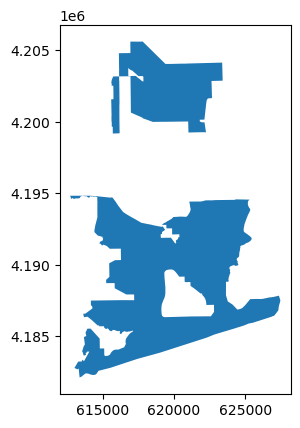

In [21]:
# pca_geo['data'][pca_geo['data']['joinkey'] == 'SL105'].plot()
pca_geo['data'][pca_geo['data']['OBJECTID'] == 187].plot()
pca_geo['data'][pca_geo['data']['OBJECTID'] == 187]

Checking natural_land
Clipped layer has 139 rows
Checking working_land
Clipped layer has 1 rows
Checking urban_greening
Clipped layer has 90 rows
Checking recreation
Clipped layer has 39 rows
Checking climate_adaptation
Clipped layer has 1 rows


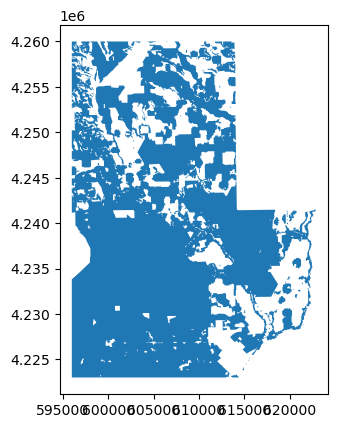

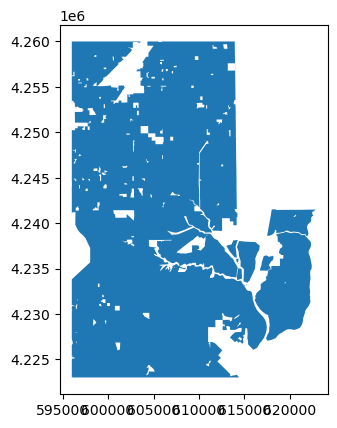

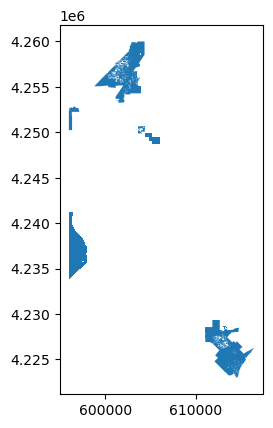

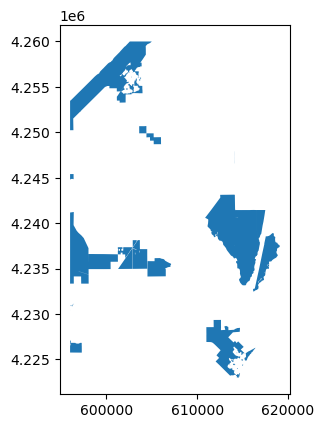

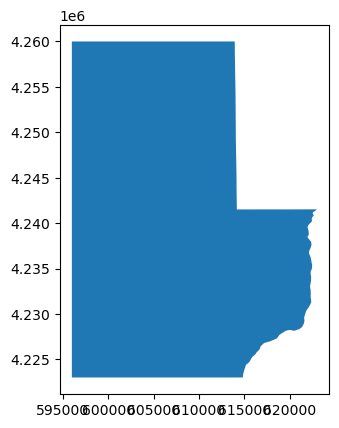

In [22]:
spot_check_square(pca_types,
                x_coords=[596000, 596000, 631000, 631000], 
                y_coords=[4223000, 4260000, 4260000, 4223000])

Checking natural_land
Clipped layer has 64 rows
Checking working_land
Clipped layer has 1 rows
Checking urban_greening
Clipped layer has 232 rows
Checking recreation
Clipped layer has 61 rows
Checking climate_adaptation
Clipped layer has 1 rows


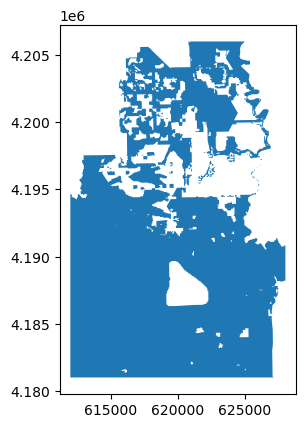

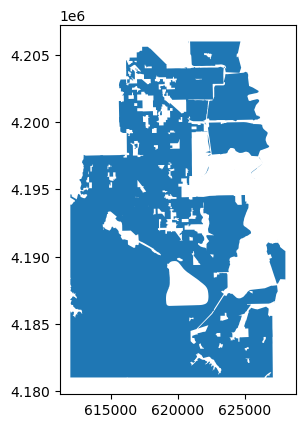

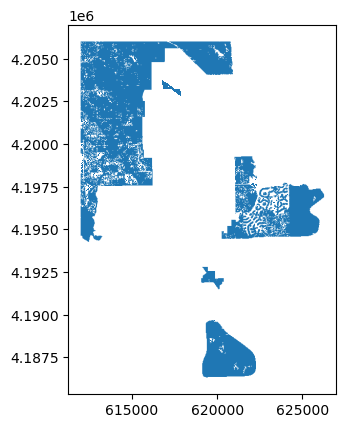

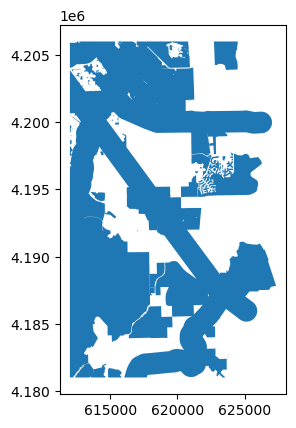

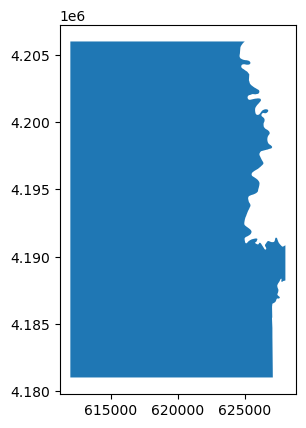

In [23]:
spot_check_square(pca_types,
                x_coords=[612000, 612000, 628000, 628000], 
                y_coords=[4181000, 4206000, 4206000, 4181000])

In [24]:
# ## Spot check
# pca_geo['data'][pca_geo['data']['joinkey'] == 'SL105'].plot()
# pca_geo['data'][pca_geo['data']['joinkey'] == 'SL105'].geometry.area

pca_geo['assignment'][['gdf_id', 'area_sq_m', '1nl',
       '1nl_intersect_sq_m', '1nl_share_pct']]

,gdf_id,area_sq_m,1nl,1nl_intersect_sq_m,1nl_share_pct
0,1,2.464613e+07,1.0,1.859041e+07,0.754293
1,2,8.162637e+07,1.0,8.098877e+07,0.992189
2,3,2.045211e+07,1.0,1.971546e+07,0.963982
3,4,5.836794e+06,1.0,2.286880e+06,0.391804
4,5,1.383711e+06,1.0,1.383711e+06,1.000000
...,...,...,...,...,...
139,140,9.638407e+06,1.0,3.356883e+05,0.034828
140,141,3.912804e+06,1.0,2.448983e+06,0.625889
141,142,2.404912e+07,1.0,2.154691e+07,0.895954
142,143,9.975664e+05,0.0,0.000000e+00,0.000000
